<a href="https://colab.research.google.com/github/financieras/articulos/blob/main/linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fundamentos de la Regresión Lineal
## Gradient Descent vs Scikit-learn en un caso práctico

---

# 1. Introducción

## 1.1 ¿Qué es la Regresión Lineal?

La regresión lineal es uno de los algoritmos fundamentales en Machine Learning. Su objetivo es encontrar la **mejor línea recta** que describe la relación entre dos variables.

Matemáticamente, buscamos una función:

$$y = w_0 + w_1 \cdot x$$

Donde:
- **$y$**: variable que queremos predecir (precio)
- **$x$**: variable conocida (metros cuadrados)
- **$w_0$**: intercepto o $bias$ (precio cuando x=0)
- **$w_1$**: pendiente (cuánto aumenta de media el precio por cada m² adicional)

## 1.2 Aplicación práctica: Predecir precios de viviendas

Imagina que eres un agente inmobiliario y necesitas estimar rápidamente el precio de una vivienda conociendo únicamente sus metros cuadrados. La regresión lineal te permite:

✓ Hacer predicciones basadas en datos históricos  
✓ Entender la relación entre tamaño y precio  
✓ Detectar viviendas sobre o infravaloradas

---

# 2. El Dataset

## 2.1 Descripción de los datos de precios de casas

Trabajaremos con un conjunto de 10 viviendas de segunda mano, donde conocemos:
- **Área**: metros cuadrados de la vivienda
- **Precio**: precio de venta en miles de dólares

## 2.2 Carga, exploración básica y visualización

Number of houses: 10
Area range: 50m² - 100m²
Price range: $140k - $300k
Average price per m²: $2.94k


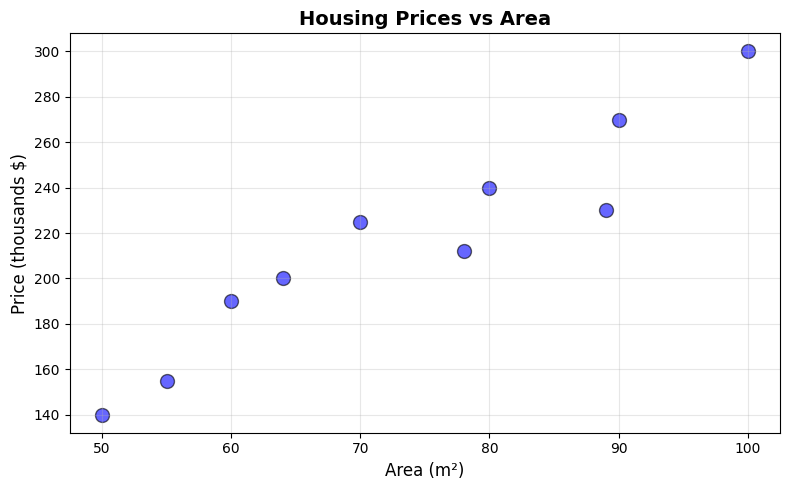

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Data: housing area (m²) vs price (thousands $)
area = np.array([50, 55, 60, 64, 70, 78, 80, 89, 90, 100])
price = np.array([140, 155, 190, 200, 225, 212, 240, 230, 270, 300])

# Basic exploration
print(f"Number of houses: {len(area)}")
print(f"Area range: {area.min()}m² - {area.max()}m²")
print(f"Price range: ${price.min()}k - ${price.max()}k")
print(f"Average price per m²: ${(price/area).mean():.2f}k")

# Visualization
plt.figure(figsize=(8, 5))
plt.scatter(area, price, color='blue', s=100, alpha=0.6, edgecolors='black')
plt.xlabel('Area (m²)', fontsize=12)
plt.ylabel('Price (thousands $)', fontsize=12)
plt.title('Housing Prices vs Area', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Observación**: Se aprecia una tendencia positiva: a mayor área, mayor precio.

## 2.3 Visualización de errores (residuos)

En el siguiente gráfico, las líneas verdes verticales muestran la diferencia entre precios reales y predichos. Buscamos la recta que haga estas diferencias al cuadrado lo más pequeñas posible.

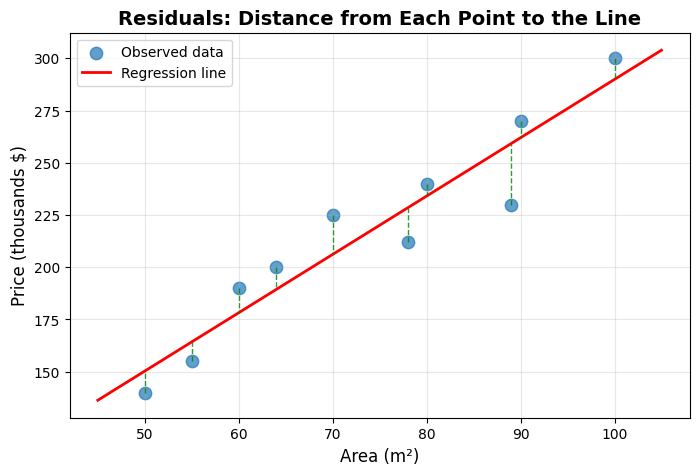

In [2]:
# @title Residuals
# Calculate regression line using the direct formula
X_matrix = np.column_stack([np.ones(len(area)), area])  # add column of 1s
w = np.linalg.inv(X_matrix.T @ X_matrix) @ X_matrix.T @ price

# Visualization with error lines
plt.figure(figsize=(8, 5))
plt.scatter(area, price, alpha=0.7, s=80, label='Observed data')

# Regression line
area_range = np.linspace(45, 105, 100)
price_range = w[0] + w[1] * area_range
plt.plot(area_range, price_range, 'r-', linewidth=2, label='Regression line')

# Vertical lines showing the errors
for xi, yi in zip(area, price):
    yi_pred = w[0] + w[1] * xi
    plt.plot([xi, xi], [yi, yi_pred], 'g--', alpha=0.8, linewidth=1)

plt.xlabel('Area (m²)', fontsize=12)
plt.ylabel('Price (thousands $)', fontsize=12)
plt.title('Residuals: Distance from Each Point to the Line', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 2.4 ¿Por qué normalizar? La importancia del escalado

Al usar Gradient Descent, las variables con escalas diferentes pueden causar problemas:

- **Sin normalizar**: Área (50-100) vs Precio (140-300)
- El algoritmo converge **lentamente** o de forma **inestable**
- El número de pasos que debe realizar el algoritmo es excesivo

**Solución: Z-score normalization**

$$z = \frac{x - \mu}{\sigma}$$

Transforma los datos para que tengan media cero ($\mu=0$) y desviación estándar uno ($\sigma=1$).

In [3]:
def normalize(data):
    mean = data.mean()
    std = data.std()
    return (data - mean) / std, mean, std

# Normalize our data
area_norm, area_mean, area_std = normalize(area)
price_norm, price_mean, price_std = normalize(price)

print(f"Original area: \t\t{area[0]}, {area[-1]}")
print(f"Normalized area: \t{area_norm[0]:.2f}, {area_norm[-1]:.2f}")
print(f"\nNormalized area:\n\tMean: {area_norm.mean():.2e} \n\tStd: {area_norm.std():.2f}")

Original area: 		50, 100
Normalized area: 	-1.51, 1.68

Normalized area:
	Mean: 3.11e-16 
	Std: 1.00


**Importante**: Guardaremos `mean` y `std` para desnormalizar las predicciones finales.

---

# 3. Conceptos clave

## 3.1 La recta de regresión

Nuestro objetivo es encontrar los parámetros **$w_0$** (intercepto) y **$w_1$** (pendiente) que mejor ajusten nuestros datos.

La predicción para cualquier valor de $x$ se calcula como:

$$\hat{y} = w_0 + w_1 \cdot x$$

Donde $\hat{y}$ es el precio predicho para una vivienda de $x$ metros cuadrados.

## 3.2 La función de Coste: midiendo el error

Para saber qué tan buena es nuestra recta, necesitamos medir el **error** entre los valores reales y las predicciones.

**Mean Squared Error (MSE)**:

$$MSE = \frac{1}{m} \sum_{i=1}^{m} (y_i - \hat{y}_i)^2$$

**Función de Coste** (la que minimizaremos):

$$J(w_0, w_1) = \frac{1}{2m} \sum_{i=1}^{m} (y_i - \hat{y}_i)^2$$

Donde:
- **$m$**: número de ejemplos (10 viviendas)
- **$y_i$**: precio real de la vivienda i
- **$\hat{y}_i$**: precio predicho de la vivienda i

El factor $\frac{1}{2}$ ayudará a simplificar las derivadas.

**Root Mean Squared Error (RMSE)**: $\sqrt{MSE}$ - métrica útil porque está en las mismas unidades que $y$ (miles de $).

## 3.3 Calculando el Gradiente

El gradiente nos indica la **dirección** en la que debemos ajustar $w_0$ y $w_1$ para reducir el error.

Las derivadas parciales de $J$ respecto a cada parámetro son:

$$\frac{\partial J}{\partial w_0} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)$$

$$\frac{\partial J}{\partial w_1} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i) \cdot x_i$$

Estas fórmulas nos dicen **cuánto y en qué dirección** cambiar cada parámetro.

## 3.4 Visualización del movimiento del gradiente

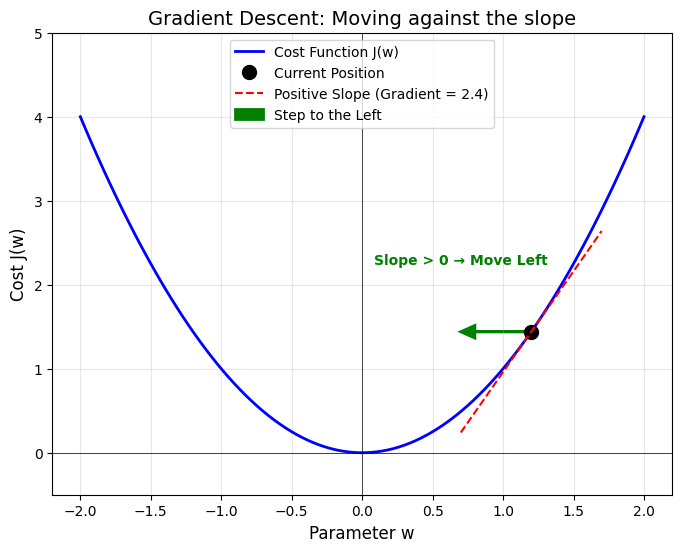

In [4]:
# @title Gradient Descent
# Visualization of gradient descent movement
weights = np.linspace(-2, 2, 100)
cost = weights**2

# Current state (a point with positive slope)
current_w = 1.2
current_cost = current_w**2
slope = 2 * current_w  # Derivative of w^2 is 2w

plt.figure(figsize=(8, 6))
plt.plot(weights, cost, 'b-', linewidth=2, label='Cost Function J(w)')
plt.plot(current_w, current_cost, 'ko', markersize=10, label='Current Position')

# Plot the tangent line (representing the gradient/slope)
tangent_range = np.linspace(current_w - 0.5, current_w + 0.5, 10)
tangent_values = current_cost + slope * (tangent_range - current_w)
plt.plot(tangent_range, tangent_values, 'r--', linewidth=1.5,
         label=f'Positive Slope (Gradient = {slope:.1f})')

# Plot the descent step (moving left)
plt.arrow(current_w, current_cost, -0.4, 0, head_width=0.15, head_length=0.1,
          fc='green', ec='green', linewidth=2, label='Step to the Left')

plt.text(current_w - 0.5, current_cost + 0.8, 'Slope > 0 → Move Left',
         color='green', fontweight='bold', ha='center')

plt.xlabel('Parameter w', fontsize=12)
plt.ylabel('Cost J(w)', fontsize=12)
plt.title('Gradient Descent: Moving against the slope', fontsize=14)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-0.5, 5)
plt.show()

**Explicación**: Cuando la pendiente (gradiente) es positiva, el mínimo está a la izquierda, por lo que nos movemos en dirección contraria (restamos). Cuando es negativa, nos movemos a la derecha (sumamos).

---

# 4. El Algoritmo: Ajustando los pesos del modelo

## 4.1 Gradient Descent

**Gradient Descent** actualiza los parámetros iterativamente:

$$w_0 := w_0 - \alpha \cdot \frac{\partial J}{\partial w_0}$$

$$w_1 := w_1 - \alpha \cdot \frac{\partial J}{\partial w_1}$$

Donde:
- **$\alpha$ (alpha)**: learning rate o tasa de aprendizaje
  - Muy pequeño → convergencia lenta
  - Muy grande → puede no converger
  - Típicamente: 0.001 - 0.1

**Proceso**:
1. Inicializar $w_0=0$, $w_1=0$
2. Calcular predicciones con los $w$ actuales
3. Calcular el gradiente (derivadas parciales)
4. Actualizar $w_0=0$, $w_1=0$
5. Repetir pasos 2-4 hasta convergencia

# 4.2 El hiperparámetro $\alpha$ (Learning Rate)

**Una analogía intuitiva**: Imagina que estás en la cima de una montaña y quieres bajar al valle, pero hay una niebla densa. No ves el camino completo, pero puedes sentir bajo tus pies hacia dónde está la pendiente más pronunciada. El **gradiente** es ese 'sentido' que te dice: "da un paso hacia esa dirección para bajar más rápido". El **learning rate ($\alpha$)** es el "tamaño del paso" que decides dar.

Si das pasos demasiado pequeños ($\alpha$ muy pequeño), llegarás al valle, pero tardarás muchísimo tiempo. Si das pasos exageradamente grandes ($\alpha$ muy grande), podrías sobrepasar el valle e incluso subir por la otra ladera. Si das pasos del tamaño adecuado ($\alpha$ óptimo), llegarás rápidamente al fondo.

El learning rate es un **hiperparámetro** que debemos ajustar manualmente, casi de forma artesanal, buscando el valor que permita una convergencia rápida y estable al óptimo en cada problema específico.

Visualicemos estos tres escenarios:

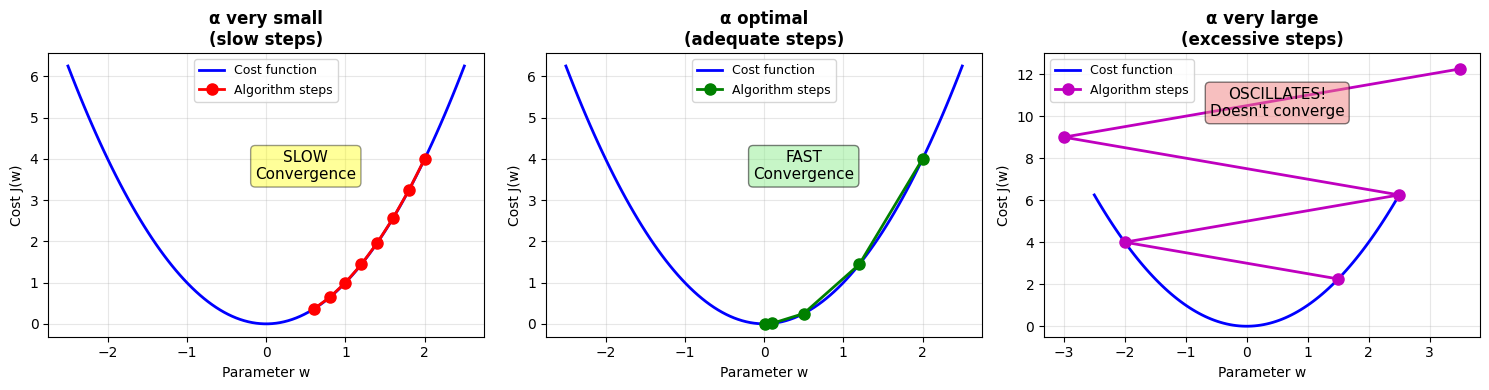

In [5]:
# @title Different Learning Rates
# Visualization of different learning rate impacts
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Simple function for demonstration (parabola)
x_range = np.linspace(-2.5, 2.5, 100)
y_func = x_range**2

# 1. Small alpha (slow convergence)
ax1 = axes[0]
ax1.plot(x_range, y_func, 'b-', linewidth=2, label='Cost function')
trayectoria_pequena = [2.0, 1.8, 1.6, 1.4, 1.2, 1.0, 0.8, 0.6]
y_pequena = [x**2 for x in trayectoria_pequena]
ax1.plot(trayectoria_pequena, y_pequena, 'ro-', markersize=8, linewidth=2,
         label='Algorithm steps')
ax1.set_title('α very small\n(slow steps)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Parameter w', fontsize=10)
ax1.set_ylabel('Cost J(w)', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=9)
ax1.text(0.5, 3.5, 'SLOW\nConvergence', fontsize=11, ha='center',
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.4))

# 2. Optimal alpha (fast convergence)
ax2 = axes[1]
ax2.plot(x_range, y_func, 'b-', linewidth=2, label='Cost function')
trayectoria_optima = [2.0, 1.2, 0.5, 0.1, 0.01]
y_optima = [x**2 for x in trayectoria_optima]
ax2.plot(trayectoria_optima, y_optima, 'go-', markersize=8, linewidth=2,
         label='Algorithm steps')
ax2.set_title('α optimal\n(adequate steps)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Parameter w', fontsize=10)
ax2.set_ylabel('Cost J(w)', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=9)
ax2.text(0.5, 3.5, 'FAST\nConvergence', fontsize=11, ha='center',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

# 3. Large alpha (oscillation/divergence)
ax3 = axes[2]
ax3.plot(x_range, y_func, 'b-', linewidth=2, label='Cost function')
trayectoria_grande = [1.5, -2.0, 2.5, -3.0, 3.5]
y_grande = [x**2 for x in trayectoria_grande]
ax3.plot(trayectoria_grande, y_grande, 'mo-', markersize=8, linewidth=2,
         label='Algorithm steps')
ax3.set_title('α very large\n(excessive steps)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Parameter w', fontsize=10)
ax3.set_ylabel('Cost J(w)', fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_ylim(-0.5, 13)
ax3.legend(fontsize=9)
ax3.text(0.5, 10, 'OSCILLATES!\nDoesn\'t converge', fontsize=11, ha='center',
         bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))

plt.tight_layout()
plt.show()

## Interpretación de los tres casos

**Izquierda ($\alpha$ muy pequeño)**: Pasos minúsculos como de hormiga. Converge eventualmente pero es ineficiente. Necesita demasiadas iteraciones.

**Centro ($\alpha$ óptimo)**: Pasos bien calibrados. En pocas iteraciones alcanza un valor cercano al óptimo. Equilibrio perfecto entre eficiencia y precisión.

**Derecha ($\alpha$ muy grande)**: Pasos exagerados que sobrepasan el mínimo repetidamente, causando oscilaciones que pueden incluso hacer divergir el algoritmo.

## Cómo encontrar el $\alpha$ adecuado

Se prueba con valores en escala logarítmica: 0.001, 0.01, 0.1, 1.0. Para nuestro problema de precios de viviendas, $\alpha$ = 0.1 funciona bien.  

**Regla práctica**: Si el coste aumenta en lugar de disminuir, reduce el learning rate. Si disminuye pero muy lentamente, auméntalo ligeramente.

---

# 5. Implementación manual con Early Stopping

## 5.1 Código del Descenso del Gradiente

In [14]:
def gradient_descent(X, y, learning_rate=0.01, iterations=1000, tolerance=1e-4):
    m = len(X)
    w_0, w_1 = 0.0, 0.0
    cost_history = []

    for i in range(iterations):
        # Predictions
        predictions = w_0 + w_1 * X

        # Calculate errors
        errors = predictions - y

        # Calculate gradients
        gradient_w0 = (1/m) * np.sum(errors)
        gradient_w1 = (1/m) * np.sum(errors * X)

        # Update parameters
        w_0 = w_0 - learning_rate * gradient_w0
        w_1 = w_1 - learning_rate * gradient_w1

        # Calculate cost (J)
        cost = (1/(2*m)) * np.sum(errors**2)
        cost_history.append(cost)

        # Early stopping (relative change in percentage)
        if i > 1 and abs(cost_history[-2] - cost) / cost_history[-2] < tolerance:
            print(f"Convergence reached at iteration {i+1}")
            break

    return w_0, w_1, cost_history

# Train the model
w_0_norm, w_1_norm, cost_history = gradient_descent(
    area_norm,
    price_norm,
    learning_rate=0.1,
    iterations=1000,
    tolerance=1e-11
)

print(f"Final parameters (normalized):")
print(f"\tw₀ (intercept) = {w_0_norm:.6f}")
print(f"\tw₁ (slope) = {w_1_norm:.6f}")

Convergence reached at iteration 125
Final parameters (normalized):
	w₀ (intercept) = -0.000000
	w₁ (slope) = 0.948757


## 5.2 Entrenamiento y visualización de resultados


Final parameters (original scale):
w₀ (intercept) = 10.72 (thousands $)
w₁ (slope) = 2.79 (thousands $ per m²)



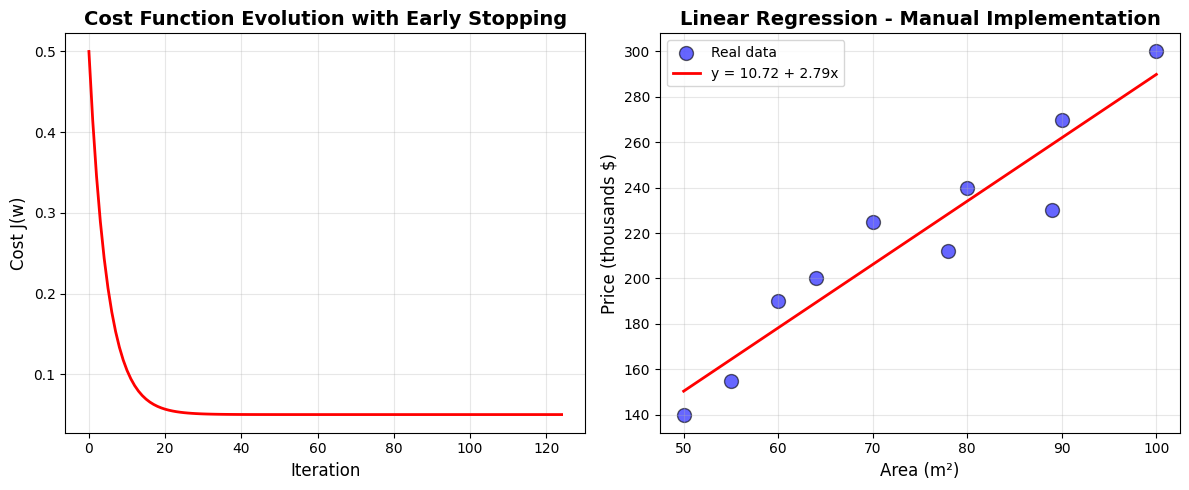

In [22]:
# Denormalize parameters to original scale
w_1_original = w_1_norm * (price_std / area_std)
w_0_original = price_mean - w_1_original * area_mean

print(f"\nFinal parameters (original scale):")
print(f"w₀ (intercept) = {w_0_original:.2f} (thousands $)")
print(f"w₁ (slope) = {w_1_original:.2f} (thousands $ per m²)\n")

# Make predictions
predictions_norm = w_0_norm + w_1_norm * area_norm
predictions = predictions_norm * price_std + price_mean

# Visualize results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Cost evolution
ax1.plot(cost_history, color='red', linewidth=2)
ax1.set_xlabel('Iteration', fontsize=12)
ax1.set_ylabel('Cost J(w)', fontsize=12)
ax1.set_title('Cost Function Evolution with Early Stopping', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Regression line
ax2.scatter(area, price, color='blue', s=100, alpha=0.6,
            edgecolors='black', label='Real data')
ax2.plot(area, predictions, color='red', linewidth=2,
         label=f'y = {w_0_original:.2f} + {w_1_original:.2f}x')
ax2.set_xlabel('Area (m²)', fontsize=12)
ax2.set_ylabel('Price (thousands $)', fontsize=12)
ax2.set_title('Linear Regression - Manual Implementation', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretación**:
- **w₁**: Por cada m² adicional, el precio aumenta aproximadamente w₁ miles de dólares
- **w₀**: Precio base (intercepto con el eje Y)
- La **curva de coste** debe decrecer y estabilizarse, indicando convergencia
- **Early Stopping**: Se detiene automáticamente cuando el cambio relativo en el coste es menor a 0.000001%

## Predicción
Vamos a calcular el precio estimado de un apartamento de 75 m² usando el modelo lineal obtenido. Solo necesitamos sustituir el valor del área ($x = 75$) en la ecuación de la recta que define nuestro modelo:  

$$\hat{y} = w_0 + w_1 \cdot 75$$

De esta forma obtenemos la predicción del precio directamente a partir de los coeficientes $w_0$ y $w_1$ calculados.

In [23]:
# Example prediction
example_area = 75
example_area_norm = (example_area - area_mean) / area_std
example_prediction_norm = w_0_norm + w_1_norm * example_area_norm
example_prediction = example_prediction_norm * price_std + price_mean

print(f"\nExample prediction:")
print(f"House of {example_area}m² → ${example_prediction:.2f}k")


Example prediction:
House of 75m² → $220.11k


# 6. Variantes del Descenso del Gradiente

Existen tres enfoques principales:

## 6.1 Batch Gradient Descent
- Usa **TODOS** los datos en cada iteración
- **Ventaja**: Dirección precisa del gradiente
- **Desventaja**: Lento con datasets grandes

## 6.2 Stochastic Gradient Descent (SGD)
- Usa **UN SOLO** punto aleatorio en cada iteración
- **Ventaja**: Muy rápido, puede escapar de mínimos locales
- **Desventaja**: Ruidoso, inestable

## 6.3 Mini-Batch Gradient Descent
- Usa un **SUBCONJUNTO** (batch) de datos (ej: 32, 64, 128 ejemplos)
- **Ventaja**: Equilibrio entre velocidad y estabilidad
- **Por qué es el más usado**: Mejor rendimiento en datasets grandes, aprovecha la vectorización de operaciones

## 6.4 Comparación de métodos

| Método | Precisión del gradiente | Velocidad | Estabilidad | Tamaño del batch |
|--------|-------------------------|-----------|-------------|------------------|
| **Batch GD** | Alta | Lenta | Alta | Todos los datos (m) |
| **Stochastic GD (SGD)** | Baja | Muy rápida | Baja | 1 ejemplo |
| **Mini-Batch GD** | Media-Alta | Rápida | Media | 16-256 ejemplos |

**Notas importantes**:
1. **Batch GD** es ideal para datasets pequeños (< 10,000 ejemplos)
2. **SGD** es útil cuando los datos llegan en streaming o son extremadamente grandes
3. **Mini-Batch GD** es el estándar en Deep Learning y la mayoría de aplicaciones prácticas
4. El tamaño del batch suele ser una potencia de 2 (32, 64, 128) por eficiencia computacional

---

# 7. Usando Scikit-learn

## 7.1 Implementación

Scikit-learn proporciona una implementación optimizada de regresión lineal que resuelve el problema con algunas ventajas:
- Más rápido: solución analítica directa
- No requiere normalización: La librería maneja automáticamente las diferencias de escala entre variables
- Sin hiperparámetros: No necesita ajustar learning rate, número de iteraciones, o tolerancias
- Código minimalista

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Create and train the model
model = LinearRegression()

# Reshape data for sklearn (requires 2D array)
X_train = area.reshape(-1, 1)
y_train = price

# Fit the model
model.fit(X_train, y_train)     # The 'fit' method works wonders

# Get parameters
w_0_sklearn = model.intercept_
w_1_sklearn = model.coef_[0]

print("Scikit-learn parameters:")
print(f"w₀ (intercept) = {w_0_sklearn:.2f} (thousands $)")
print(f"w₁ (slope) = {w_1_sklearn:.2f} (thousands $ per m²)")

Scikit-learn parameters:
w₀ (intercept) = 10.72 (thousands $)
w₁ (slope) = 2.79 (thousands $ per m²)


## 7.2 Entrenamiento y predicciones
Una vez entrenado el modelo, podemos evaluar su rendimiento y hacer predicciones con datos no vistos hasta ahora.

In [9]:
# Make predictions
predictions_sklearn = model.predict(X_train)

# Calculate metrics
mse_sklearn = mean_squared_error(y_train, predictions_sklearn)
rmse_sklearn = np.sqrt(mse_sklearn)
r2_sklearn = r2_score(y_train, predictions_sklearn)

print(f"\nMetrics:")
print(f"MSE = {mse_sklearn:.2f}")
print(f"RMSE = {rmse_sklearn:.2f} (thousands $)")
print(f"R² = {r2_sklearn:.4f}")

# Example prediction
example_prediction_sklearn = model.predict([[75]])[0]
print(f"\nExample prediction:")
print(f"House of 75m² → ${example_prediction_sklearn:.2f}k")


Metrics:
MSE = 212.39
RMSE = 14.57 (thousands $)
R² = 0.9001

Example prediction:
House of 75m² → $220.11k


---

# 8. Comparación y evaluación

## 8.1 Resultados lado a lado

                   Method  w₀ (intercept)  w₁ (slope)
Manual (Gradient Descent)       10.723238    2.791804
             Scikit-learn       10.722846    2.791809

Metrics comparison:
Method                         MSE        RMSE       R²        
Manual (Gradient Descent)      212.39     14.57      0.9001    
Scikit-learn                   212.39     14.57      0.9001    


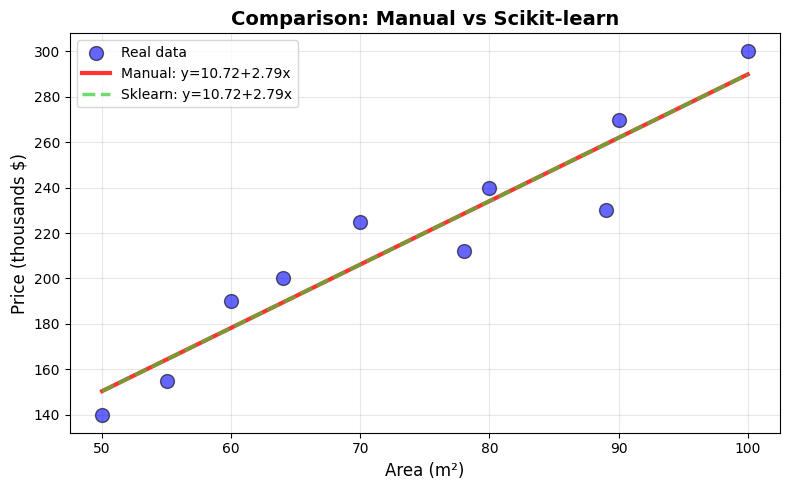

In [20]:
# @title Compare parameters
import pandas as pd
comparison_df = {
    'Method': ['Manual (Gradient Descent)', 'Scikit-learn'],
    'w₀ (intercept)': [w_0_original, w_0_sklearn],
    'w₁ (slope)': [w_1_original, w_1_sklearn]
}

df = pd.DataFrame(comparison_df)
print(df.to_string(index=False))

# Calculate metrics for manual implementation
mse_manual = mean_squared_error(price, predictions)
rmse_manual = np.sqrt(mse_manual)
r2_manual = r2_score(price, predictions)

print(f"\nMetrics comparison:")
print(f"{'Method':<30} {'MSE':<10} {'RMSE':<10} {'R²':<10}")
print(f"{'='*60}")
print(f"{'Manual (Gradient Descent)':<30} {mse_manual:<10.2f} {rmse_manual:<10.2f} {r2_manual:<10.4f}")
print(f"{'Scikit-learn':<30} {mse_sklearn:<10.2f} {rmse_sklearn:<10.2f} {r2_sklearn:<10.4f}")

# Visual comparison
plt.figure(figsize=(8, 5))
plt.scatter(area, price, color='blue', s=100, alpha=0.6,
            edgecolors='black', label='Real data', zorder=3)
plt.plot(area, predictions, color='red', linewidth=3,  # Más gruesa
         label=f'Manual: y={w_0_original:.2f}+{w_1_original:.2f}x',
         linestyle='-', alpha=0.8)  # Línea sólida + transparencia
plt.plot(area, predictions_sklearn, color='limegreen', linewidth=2.5,  # Un poco más delgada
         label=f'Sklearn: y={w_0_sklearn:.2f}+{w_1_sklearn:.2f}x',
         linestyle='--', alpha=0.7)  # Línea punteada + transparencia
plt.xlabel('Area (m²)', fontsize=12)
plt.ylabel('Price (thousands $)', fontsize=12)
plt.title('Comparison: Manual vs Scikit-learn', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 8.2 Métricas: R² e interpretaciones

**Coeficiente de Determinación (R²)**:

$$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$

**Interpretación**:
- **R² ≈ 1**: Ajuste perfecto (predicciones exactas)
- **R² ≈ 0.9**: Excelente ajuste (nuestro caso: explica el 90% de las variaciones en precios)
- **R² ≈ 0.7-0.8**: Buen ajuste para aplicaciones prácticas
- **R² < 0.5**: Ajuste débil (considerar más variables o modelos)

R² se interpreta directamente en porcentaje: **R² = 0.90 significa que el 90% de las diferencias en precios se explican por el área**. El 10% restante depende de factores no considerados (ubicación, estado, etc.).

**Observación**: Ambos métodos convergen a resultados prácticamente idénticos. Las pequeñas diferencias se deben a:
- Gradient Descent: aproximación iterativa
- Scikit-learn: solución analítica exacta

---

# 9. Conclusión

## 9.1 Correlación no es causalidad

Aunque encontramos una relación fuerte entre área y precio, debemos ser cautelosos:

- **Correlación**: Existe una relación estadística (R² alto)
- **Causalidad**: No podemos afirmar que el área *causa* el precio

**Factores omitidos** que también influyen:
- Ubicación de la vivienda
- Estado de conservación
- Año de construcción
- Servicios cercanos

**Ejemplo de correlación espuria**: El consumo de helado correlaciona con ahogamientos en piscinas, pero el helado no *causa* ahogamientos. Ambos aumentan en verano.

> Más ejemplos: [tylervigen.com/spurious-correlations](https://www.tylervigen.com/spurious-correlations)

## 9.2 Cuándo usar regresión lineal

**✓ Usar regresión lineal cuando:**
- La relación entre variables es aproximadamente lineal
- Necesitas un modelo interpretable y simple
- Tienes pocas variables predictoras
- Quieres entender la magnitud del efecto de cada variable

**✗ Evitar regresión lineal cuando:**
- La relación es claramente no lineal (curvas, exponenciales)
- Tienes muchas variables correlacionadas entre sí
- Los datos tienen patrones complejos

## 9.3 Resumen práctico

1. **Para aprender**: Implementa Gradient Descent manualmente (entenderás mejor cómo funciona)
2. **Para proyectos reales**: Usa Scikit-learn (es más rápido y robusto)
3. **Para datasets grandes**: Considera Mini-Batch Gradient Descent
4. **Siempre**: Visualiza tus datos, evalúa métricas (R², RMSE) y cuestiona tus resultados


**Reflexión:**  
- En este mundo de IA y redes neuronales profundas, la regresión lineal continúa siendo una herramienta fundamental del Machine Learning. Se sigue usando extensamente por sus magníficos resultados y, especialmente, por la explicabilidad del modelo que genera.
- Cuando otros hablan de "cajas negras" en modelos complejos, tú podrás explicar exactamente cómo tu modelo de regresión toma decisiones: "Por cada metro cuadrado adicional, el precio aumenta X dólares". Esa claridad tiene un valor inmenso en aplicaciones reales.